In [1]:
import os, pickle

from physics.simulation import msq, sample
from physics.hzz import zpair, zz4l
from alice import dataset, model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist

import torch
from torch.utils.data import TensorDataset
from lightning import Trainer

In [2]:
OUTPUT_DIR = 'jobs/alice/refactor-one-500k'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '..'

CHECKPOINT = 'checkpoint-alice-epoch=54-val_loss=0.47.ckpt'

VERSION = 0
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

COMPONENT_2 = msq.Component.SIG
COMPONENT_1 = msq.Component.BKG

SAMPLE_SIZE = 250000
BATCH_SIZE = 128
SEED = 42

In [3]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

cmp_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [4]:
sample_background = sample.from_csv(cross_section=xs[COMPONENT_2], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_2]), n_rows=int(SAMPLE_SIZE*1.2))

msq_bkg_null = msq.MSQFilter('msq_bkg_sm', 0.0)

z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

sample_processed = sample_background.filter(msq_bkg_null).calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

X = sample_processed.kinematics[features].to_numpy()

with open(os.path.join(OUTPUT_DIR, SCALER_FILE), 'rb') as f:
    scaler = pickle.load(f)

X_scaled = scaler.transform(X)

0.1509509655836949


In [5]:
model_alice = model.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [6]:
predictions = model_alice(torch.tensor(X_scaled, dtype=torch.float32)).detach().view(-1).numpy()
ratio_predicted = predictions/(1-predictions)

In [13]:
SIG_weights_predicted = sample_processed.reweight(COMPONENT_2, COMPONENT_1).weights.to_numpy() * ratio_predicted
SIG_weights_reweight = sample_processed.reweight(COMPONENT_2, COMPONENT_1).weights.to_numpy() * (sample_processed.probabilities.to_numpy()/sample_processed.reweight(COMPONENT_2, COMPONENT_1).probabilities.to_numpy())

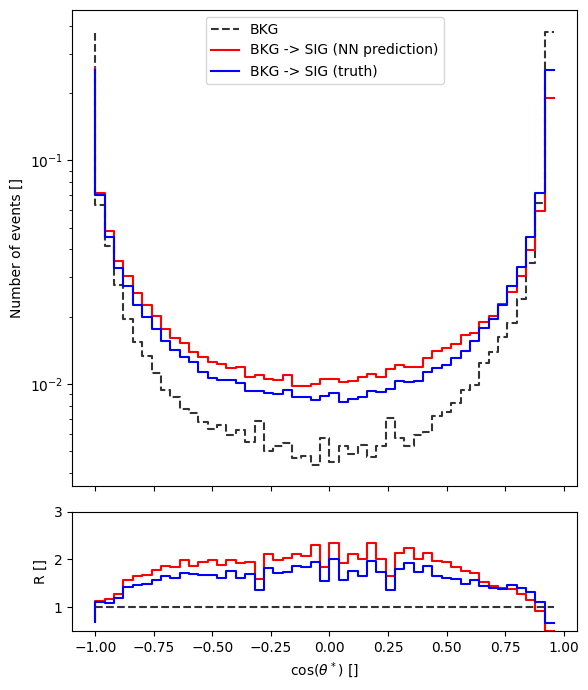

In [32]:
index = 0

kin_var = X[:,index]
label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_4{\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [180,1000],
          [-2.4,2.4]][index]


BINS=50

hist_bkg, bins = np.histogram(kin_var, bins=BINS, range=bounds, weights=sample_processed.reweight(COMPONENT_2, COMPONENT_1).weights)
hist_pred, bins = np.histogram(kin_var, bins=BINS, range=bounds, weights=SIG_weights_predicted/np.sum(SIG_weights_predicted)*np.sum(SIG_weights_reweight))
hist_rew, bins = np.histogram(kin_var, bins=BINS, range=bounds, weights=SIG_weights_reweight)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_bkg, color='black', linestyle='--', label=f'{cmp_names[COMPONENT_1]}', alpha=0.8)
ax1.step(bins[:-1], hist_pred, color='r', label=f'{cmp_names[COMPONENT_1]} -> {cmp_names[COMPONENT_2]} (NN prediction)')
ax1.step(bins[:-1], hist_rew, color='b', label=f'{cmp_names[COMPONENT_1]} -> {cmp_names[COMPONENT_2]} (truth)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
#ax1.set_ylim(0,10)

ax1.legend()

ax2.step(bins[:-1], hist_bkg/hist_bkg, color='black', linestyle='--', label=f'{cmp_names[COMPONENT_1]}', alpha=0.8)
ax2.step(bins[:-1], hist_pred/hist_bkg, color='r', label=f'{cmp_names[COMPONENT_1]} -> {cmp_names[COMPONENT_2]} (NN prediction)')
ax2.step(bins[:-1], hist_rew/hist_bkg, color='b', label=f'{cmp_names[COMPONENT_1]} -> {cmp_names[COMPONENT_2]} (truth)')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(0.5,3.0)
fig.tight_layout()

plt.show()